In [ ]:
# Import the necessary libraries for data manipulation and numerical operations
import numpy as np
import pandas as pd

In [ ]:
# Load the electrical fault dataset from a CSV file into a pandas DataFrame
df=pd.read_csv("/content/classData.csv")

Viewing features of dataset

In [ ]:
# Display the first 5 rows of the DataFrame to inspect the data and its structure
df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [ ]:
# Display concise summary of the DataFrame, including column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB


In [ ]:
# Count the occurrences of each unique combination of the fault binary indicators (G, C, B, A)
df[['G','C','B','A']].value_counts()

G  C  B  A
0  0  0  0    2365
1  0  1  1    1134
   1  1  1    1133
   0  0  1    1129
0  1  1  1    1096
         0    1004
Name: count, dtype: int64

In [ ]:
# Define a function to classify the specific type of electrical fault based on the binary indicators G, C, B, and A
def fault_type(row):
    if (row['G'],row['C'],row['B'],row['A']) == (0,0,0,0):
        return "No Fault"
    elif (row['G'],row['C'],row['B'],row['A']) == (1,0,0,1):
        return "LG"
    elif (row['G'],row['C'],row['B'],row['A']) == (0,0,1,1):
        return "LL"
    elif (row['G'],row['C'],row['B'],row['A']) == (1,0,1,1):
        return "LLG"
    elif (row['G'],row['C'],row['B'],row['A']) == (0,1,1,1):
        return "LLL"
    elif (row['G'],row['C'],row['B'],row['A']) == (1,1,1,1):
        return "LLLG"

In [ ]:
# Apply the fault_type function to each row of the DataFrame to create a new target 'fault_type' column
df['fault_type']=df.apply(fault_type,axis=1)

In [ ]:
df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,fault_type
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,LG
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,LG
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,LG
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,LG
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,LG


In [ ]:
# Import the pyplot module from matplotlib for data visualization
import matplotlib.pyplot as plt

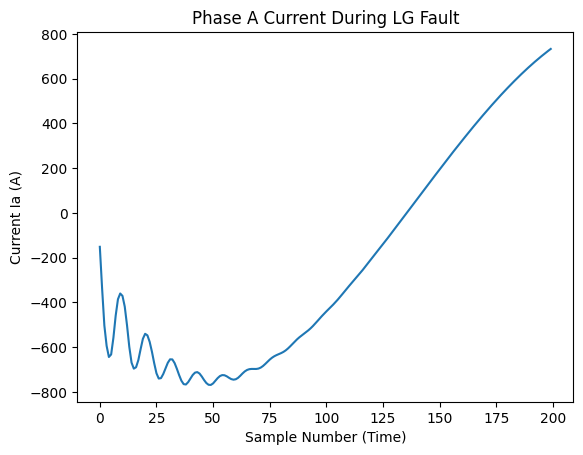

In [ ]:
# Filter the data for Line-to-Ground (LG) faults and plot the first 200 samples of Phase A current (Ia)
lg_fault=df[df['fault_type']=='LG']
plt.plot(lg_fault['Ia'][:200])

plt.xlabel("Sample Number (Time)")
plt.ylabel("Current Ia (A)")
plt.title("Phase A Current During LG Fault")
plt.show()


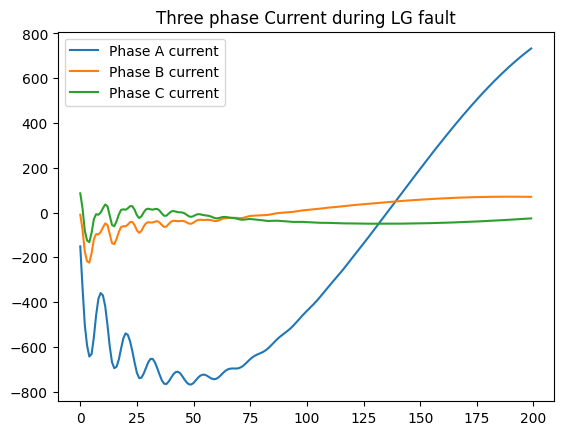

In [ ]:
plt.plot(lg_fault['Ia'][:200],label='Phase A current')
plt.plot(lg_fault['Ib'][:200],label='Phase B current')
plt.plot(lg_fault['Ic'][:200],label='Phase C current')
plt.legend()
plt.title("Three phase Current during LG fault")
plt.show()

Extract normal data

In [ ]:
normal = df[df['fault_type'] == 'No Fault']

In [ ]:
print(normal.shape)

(2365, 11)


In [ ]:
print(df['fault_type'].unique())

['LG' 'LLG' None 'LLL' 'LLLG' 'No Fault']


In [ ]:
print(normal['Ia'][:10])

5496    61.806321
5497    48.041678
5498    34.256533
5499    20.464350
5500     7.109677
5501    -5.108687
5502   -15.628492
5503   -24.522932
5504   -32.256760
5505   -38.871156
Name: Ia, dtype: float64


plot normal data vs LG fault data

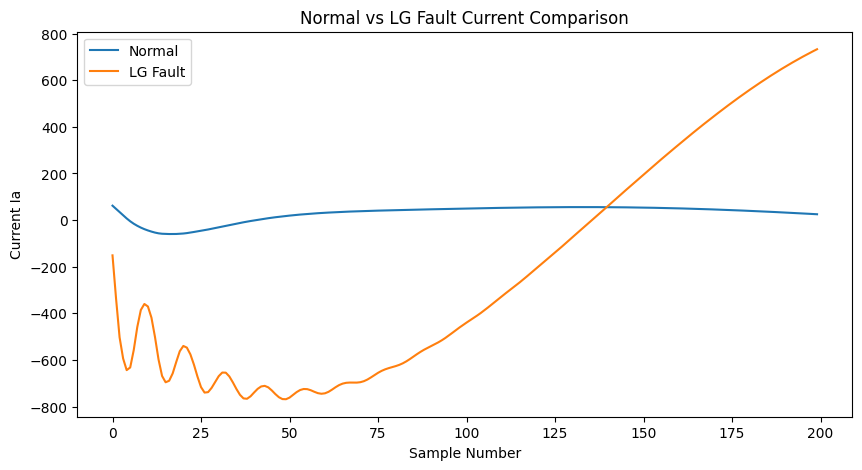

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(normal['Ia'].reset_index(drop=True)[:200], label='Normal')
plt.plot(lg_fault['Ia'].reset_index(drop=True)[:200], label='LG Fault')

plt.xlabel("Sample Number")
plt.ylabel("Current Ia")
plt.title("Normal vs LG Fault Current Comparison")

plt.legend()
plt.show()

In [ ]:
df['fault_type'].value_counts()

,count
fault_type,
No Fault,2365
LLG,1134
LLLG,1133
LG,1129
LLL,1096


Creating Current magnitude

In [ ]:
import numpy as np

df['I_mag'] = np.sqrt(df['Ia']**2 + df['Ib']**2 + df['Ic']**2)

Compare Magnitude

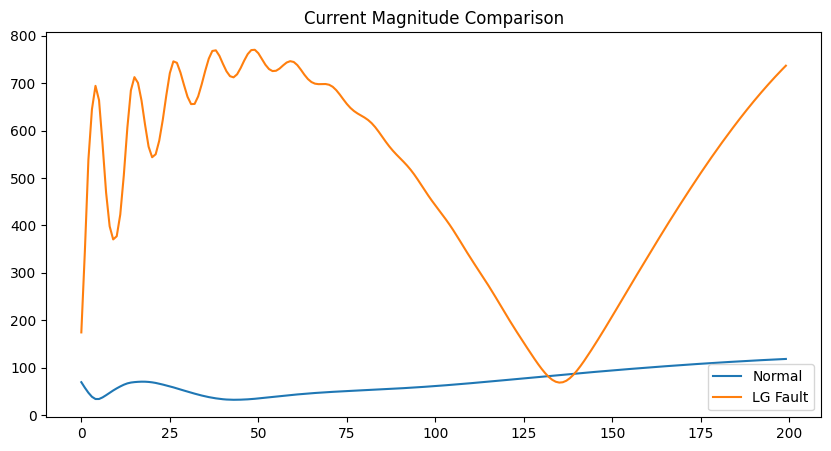

In [ ]:
plt.figure(figsize=(10,5))

# Redefine normal and lg_fault to include the 'I_mag' column
normal = df[df['fault_type'] == 'No Fault']
lg_fault = df[df['fault_type'] == 'LG']

plt.plot(normal['I_mag'].reset_index(drop=True)[:200], label='Normal')
plt.plot(lg_fault['I_mag'].reset_index(drop=True)[:200], label='LG Fault')

plt.legend()
plt.title("Current Magnitude Comparison")

plt.show()

In [ ]:
df['v_imbalance']=df[['Va','Vb','Vc']].std(axis=1)

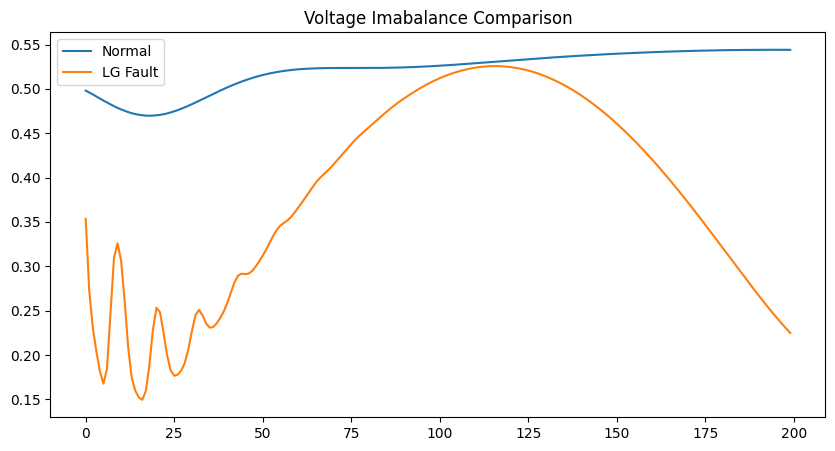

In [ ]:
plt.figure(figsize=(10,5))

# Redefine normal and lg_fault to include the 'v_imbalance' column
normal = df[df['fault_type'] == 'No Fault']
lg_fault = df[df['fault_type'] == 'LG']

plt.plot(normal['v_imbalance'].reset_index(drop=True)[:200], label='Normal')
plt.plot(lg_fault['v_imbalance'].reset_index(drop=True)[:200], label='LG Fault')

plt.legend()
plt.title("Voltage Imabalance Comparison")

plt.show()

Combining all features

In [ ]:
features=['Ia','Ib','Ic','Va','Vb','Vc','I_mag','v_imbalance']
X=df[features]
y=df['fault_type']

Training Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

Fitting model

In [ ]:
model=RandomForestClassifier()

# Filter out None values from y_train and corresponding X_train rows
valid_indices = y_train.notna()
X_train = X_train[valid_indices]
y_train = y_train[valid_indices]

model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import classification_report

# Create a boolean mask for non-null values in y_test
valid_mask = y_test.notna()

# Get the indices where y_test is not null
# This ensures alignment by explicitly using the index values that are common
# to both X_test and y_test after train_test_split.
valid_indices_for_filter = y_test[valid_mask].index

# Filter both X_test and y_test using these aligned indices
X_test_filtered = X_test.loc[valid_indices_for_filter]
y_test_filtered = y_test.loc[valid_indices_for_filter]

# Make predictions on the filtered X_test
y_pred = model.predict(X_test_filtered)

# Print the classification report using the filtered y_test
print(classification_report(y_test_filtered, y_pred))

              precision    recall  f1-score   support

          LG       1.00      1.00      1.00       242
         LLG       1.00      1.00      1.00       238
         LLL       0.79      0.81      0.80       199
        LLLG       0.82      0.79      0.80       211
    No Fault       1.00      1.00      1.00       482

    accuracy                           0.94      1372
   macro avg       0.92      0.92      0.92      1372
weighted avg       0.94      0.94      0.94      1372



In [ ]:
import pandas as pd
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

,0
I_mag,0.278450
v_imbalance,0.251697
Ic,0.108889
Ib,0.105542
Ia,0.073951
Va,0.073601
Vb,0.056066
Vc,0.051804


Updating features of model to reduce LLL and LLLG confusion

adding phase difference feature

In [ ]:
df['Ia_Ib_diff']=abs(df['Ia']-df['Ib'])
df['Ib_Ic_diff']=abs(df['Ib']-df['Ic'])
df['Ia_Ic_diff']=abs(df['Ia']-df['Ic'])

adding voltage difference

In [ ]:
df['Va_Vb_diff']=abs(df['Va']-df['Vb'])
df['Vb_Vc_diff']=abs(df['Vb']-df['Vc'])
df['Va_Vc_diff']=abs(df['Va']-df['Vc'])

In [ ]:
features=['Ia','Ib','Ic','Va','Vb','Vc','I_mag','v_imbalance',
          'Ia_Ib_diff','Ib_Ic_diff','Ia_Ic_diff',
          'Va_Vb_diff','Vb_Vc_diff','Va_Vc_diff']
X=df[features]
y=df['fault_type']
model=RandomForestClassifier() # Instantiate the classifier


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# Filter out None values from y_train and corresponding X_train rows
valid_indices = y_train.notna()
X_train = X_train[valid_indices]
y_train = y_train[valid_indices]

model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
valid_mask = y_test.notna()
valid_indices_for_filter = y_test[valid_mask].index
X_test_filtered = X_test.loc[valid_indices_for_filter]
y_test_filtered = y_test.loc[valid_indices_for_filter]

In [ ]:
y_pred = model.predict(X_test_filtered)
print(classification_report(y_test_filtered, y_pred))

              precision    recall  f1-score   support

          LG       1.00      1.00      1.00       242
         LLG       1.00      1.00      1.00       238
         LLL       0.79      0.79      0.79       199
        LLLG       0.80      0.80      0.80       211
    No Fault       1.00      1.00      1.00       482

    accuracy                           0.94      1372
   macro avg       0.92      0.92      0.92      1372
weighted avg       0.94      0.94      0.94      1372



there was no improvment because RandomForest model is smart enough to figure out relationship between Ia ,Ib and Ic ,so there was no effect of adding this feature

**Adding ratio features**

In [ ]:
df['Ia_ratio'] = df['Ia'] / (df['Ib'] + df['Ic'] + 1e-6)
df['Ib_ratio'] = df['Ib'] / (df['Ia'] + df['Ic'] + 1e-6)
df['Ic_ratio'] = df['Ic'] / (df['Ia'] + df['Ib'] + 1e-6)

In [ ]:
features=['Ia','Ib','Ic','Va','Vb','Vc','I_mag','v_imbalance',
          'Ia_Ib_diff','Ib_Ic_diff','Ia_Ic_diff',
          'Va_Vb_diff','Vb_Vc_diff','Va_Vc_diff','Ia_ratio','Ib_ratio','Ic_ratio']
X=df[features]
y=df['fault_type']
model=RandomForestClassifier() # Instantiate the classifier

# Re-run train_test_split to use the updated X and y with new features.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# Filter out None values from y_train and corresponding X_train rows
valid_indices = y_train.notna()
X_train = X_train[valid_indices]
y_train = y_train[valid_indices]

model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
valid_mask = y_test.notna()
valid_indices_for_filter = y_test[valid_mask].index
X_test_filtered = X_test.loc[valid_indices_for_filter]
y_test_filtered = y_test.loc[valid_indices_for_filter]

In [ ]:
y_pred = model.predict(X_test_filtered)
print(classification_report(y_test_filtered, y_pred))

              precision    recall  f1-score   support

          LG       1.00      1.00      1.00       242
         LLG       1.00      1.00      1.00       238
         LLL       0.99      1.00      1.00       199
        LLLG       1.00      0.99      1.00       211
    No Fault       1.00      1.00      1.00       482

    accuracy                           1.00      1372
   macro avg       1.00      1.00      1.00      1372
weighted avg       1.00      1.00      1.00      1372



In [ ]:
print(df.duplicated().sum())

0


In [ ]:
from sklearn.model_selection import cross_val_score

# Filter out None values from y and corresponding X rows for cross-validation
valid_indices_cv = y.notna()
X_filtered_cv = X[valid_indices_cv]
y_filtered_cv = y[valid_indices_cv]

scores = cross_val_score(model, X_filtered_cv, y_filtered_cv, cv=5)
print(scores)
print(scores.mean())


[0.91399417 0.99854227 1.         1.         0.80306346]
0.9431199800958208


In [ ]:
import joblib
import os

# Create the directory if it doesn't exist
os.makedirs("model", exist_ok=True)

joblib.dump(model, "model/fault_model.pkl")

['model/fault_model.pkl']